In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam,SGD
from keras.utils import to_categorical
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
data=pd.read_csv("diabetes.csv")

In [4]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
x=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)

In [7]:
x.shape,y.shape

((768, 8), (768,))

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
x_train.shape

(614, 8)

##3 regularization

In [10]:
import tensorflow
from tensorflow.keras.models import Sequential
model1=Sequential()

l1_regularizer=tensorflow.keras.regularizers.l1(0.001)
model1.add(Dense(128,input_dim=8,activation="relu",kernel_regularizer=l1_regularizer))
model1.add(Dense(128,activation="relu",kernel_regularizer=l1_regularizer))
model1.add(Dense(1,activation="sigmoid"))

model1.summary()


C:\Users\HibaA\.ipython\anaconda123\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model1.compile(loss="mse",optimizer=Adam(learning_rate=0.01),metrics=["mse"])
history=model1.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),verbose=1)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.8101 - mse: 0.1704 - val_loss: 0.4206 - val_mse: 0.1636
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3208 - mse: 0.1558 - val_loss: 0.2668 - val_mse: 0.1631
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2333 - mse: 0.1522 - val_loss: 0.2342 - val_mse: 0.1667
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2132 - mse: 0.1534 - val_loss: 0.2345 - val_mse: 0.1746
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2056 - mse: 0.1514 - val_loss: 0.2110 - val_mse: 0.1659
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1940 - mse: 0.1512 - val_loss: 0.2042 - val_mse: 0.1647
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1887 - mse: 0.1503 - val_loss: 0.2040 - val_mse: 0.1643
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1855 - mse: 0.1471 - val_loss: 0.1980 - val_mse: 0.1618
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.184

In [12]:
model2=Sequential()


model2.add(Dense(128,input_dim=8,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(128,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(1,activation="sigmoid"))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model2.compile(loss="mse",optimizer=Adam(learning_rate=0.01),metrics=["mse"])
history=model2.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),verbose=1)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.2689 - mse: 0.1744 - val_loss: 0.2274 - val_mse: 0.1738
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1998 - mse: 0.1609 - val_loss: 0.1849 - val_mse: 0.1589
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1682 - mse: 0.1469 - val_loss: 0.1874 - val_mse: 0.1692
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1645 - mse: 0.1476 - val_loss: 0.1789 - val_mse: 0.1645
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1576 - mse: 0.1430 - val_loss: 0.1995 - val_mse: 0.1865
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1625 - mse: 0.1499 - val_loss: 0.1932 - val_mse: 0.1795
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1566 - mse: 0.1427 - val_loss: 0.1800 - val_mse: 0.1673
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1595 - mse: 0.1474 - val_loss: 0.1879 - val_mse: 0.1757
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.159

#### dropout and batch normalization

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.optimizers import Adam
model=Sequential()
model.add(Dense(64,activation="relu",input_dim=8))
model.add(Dropout(0.2)) #dropout layer with 20% dropout rate
model.add(BatchNormalization())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Dense(1,activation="linear"))
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,793 (38.25 KB)

 Trainable params: 9,409 (36.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping
callback=EarlyStopping(monitor="val_loss",
                       patience=5,
                       restore_best_weights=True,
                       verbose=1,
                       mode="auto",
                       baseline=None)

In [19]:
from tensorflow.keras.optimizers import Adam
Adam=Adam(learning_rate=0.01)
model.compile(loss="mse",optimizer=Adam,metrics=["mse"])
history=model.fit(x_train,y_train,epochs=50,validation_data=(x_test,y_test),
                  verbose=1,
                  callbacks=[callback])

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 1.2348 - mse: 1.2348 - val_loss: 0.2157 - val_mse: 0.2157
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4199 - mse: 0.4199 - val_loss: 0.1967 - val_mse: 0.1967
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2280 - mse: 0.2280 - val_loss: 0.1879 - val_mse: 0.1879
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2008 - mse: 0.2008 - val_loss: 0.1825 - val_mse: 0.1825
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1853 - mse: 0.1853 - val_loss: 0.1895 - val_mse: 0.1895
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1722 - mse: 0.1722 - val_loss: 0.1923 - val_mse: 0.1923
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1764 - mse: 0.1764 - val_loss: 0.1753 - val_mse: 0.1753
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1702 - mse: 0.1702 - val_loss: 0.1816 - val_mse: 0.1816
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1757 

In [21]:
# evaluate the model
_,train_mse=model.evaluate(x_train,y_train,verbose=0)
_,test_mse=model.evaluate(x_test,y_test,verbose=0)
print("Train:{},Test:{}".format(train_mse,test_mse))

Train:0.14441467821598053,Test:0.17015725374221802


In [22]:
model.evaluate(x_test,y_test,verbose=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1702 - mse: 0.1702


[0.17015725374221802, 0.17015725374221802]

In [24]:
y_pred=model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [25]:
y_pred

array([[ 0.3891855 ],
       [ 0.09654684],
       [ 0.1680842 ],
       [ 0.18933305],
       [ 0.39060628],
       [ 0.43034703],
       [-0.10967533],
       [ 0.7128486 ],
       [ 0.50433195],
       [ 0.5080505 ],
       [ 0.15993321],
       [ 0.671759  ],
       [ 0.4026329 ],
       [ 0.31031552],
       [ 0.05062032],
       [ 0.4196886 ],
       [ 0.10518035],
       [ 0.05115671],
       [ 0.92876583],
       [ 0.5452533 ],
       [ 0.21168627],
       [ 0.07353137],
       [ 0.5260861 ],
       [ 0.04394192],
       [ 0.54041934],
       [ 0.7504834 ],
       [ 0.02371812],
       [-0.04012649],
       [ 0.26687685],
       [ 0.15795898],
       [ 0.9539059 ],
       [ 0.61765975],
       [ 0.82720166],
       [ 1.0031796 ],
       [ 0.51615494],
       [ 0.65456295],
       [ 0.98650247],
       [ 0.2869179 ],
       [ 0.19678056],
       [ 0.9801095 ],
       [ 0.01253673],
       [ 0.44217807],
       [ 0.2712422 ],
       [ 0.25192764],
       [-0.03895524],
       [ 0

In [26]:
x_train.shape,y_train.shape

((614, 8), (614,))

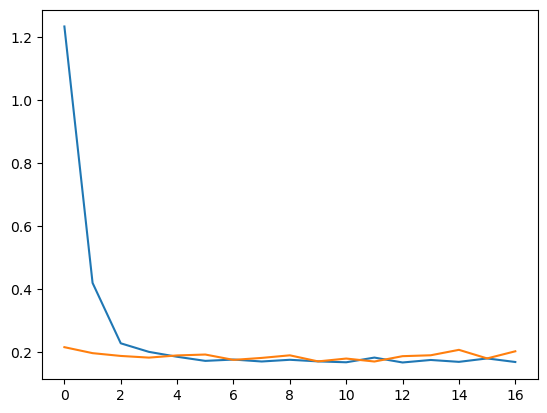

In [28]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])